In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('Langchain_Perfected_Freshness_Dataset.csv' )
df.head()

,received_date,expiry_date,product,category,shelf_life_days,stock_quantity,sales_volume,unit_price,freshness_score,sales_demand_n,...,base_profit_margin,waste_quantity,Days_to_Expiry_at_Sale,discount_applied_percent,promotional_price,final_profit,supplier_id,lead_time_days,expected_delivery_date,supply_delay_days
0,2022-12-12,2023-12-12,All-Purpose Flour,Pantry,365,67,12,205,0.000000,1,...,83.30,55,357,0,205.00,999.60,Supplier_A,2,2022-12-12,0
1,2022-12-15,2023-12-15,All-Purpose Flour,Pantry,365,53,13,246,0.000000,1,...,64.53,40,324,0,246.00,838.89,Supplier_D,4,2022-12-15,0
2,2022-12-16,2023-12-16,All-Purpose Flour,Pantry,365,45,9,193,0.000000,1,...,61.18,36,197,0,193.00,550.62,Supplier_B,3,2022-12-15,1
3,2023-01-10,2024-01-10,All-Purpose Flour,Pantry,365,87,11,189,2.465753,1,...,66.21,76,213,0,189.00,728.31,Supplier_D,3,2023-01-10,0
4,2023-03-27,2024-03-26,All-Purpose Flour,Pantry,365,46,7,223,23.287671,1,...,102.80,39,219,5,211.85,641.55,Supplier_B,2,2023-03-27,0


In [3]:
%pip install langchain langchain-experimental langchain-huggingface huggingface-hub pandas

Note: you may need to restart the kernel to use updated packages.


# Step 2: Waste Hotspot Analysis (Spatial & Categorical)
**Tagline:** Identifying where and what is driving inventory waste.

**Description:** To train the Inventory and Decision Agents, we must isolate the highest waste-producing locations and product categories. This aggregates `waste_quantity` by store and category to prioritize redistribution and discounting targets.

C:\Users\sanke\AppData\Local\Temp\ipykernel_22448\1950966641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=waste_by_store.index, y=waste_by_store.values, palette='Reds_r')


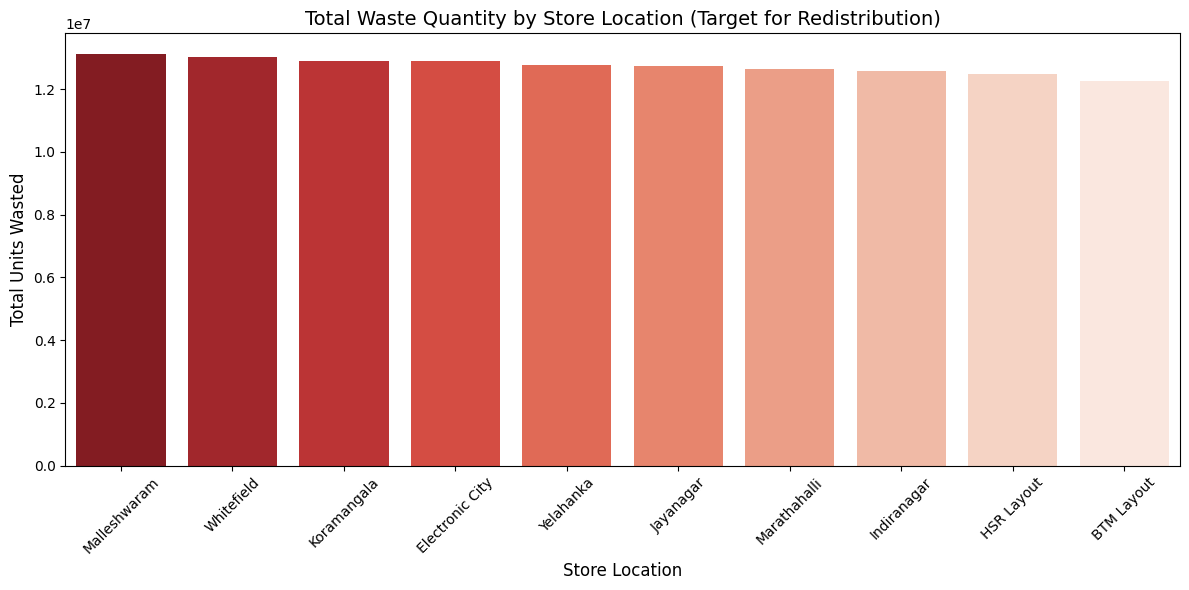

C:\Users\sanke\AppData\Local\Temp\ipykernel_22448\1950966641.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=waste_by_category.index, y=waste_by_category.values, palette='Oranges_r')


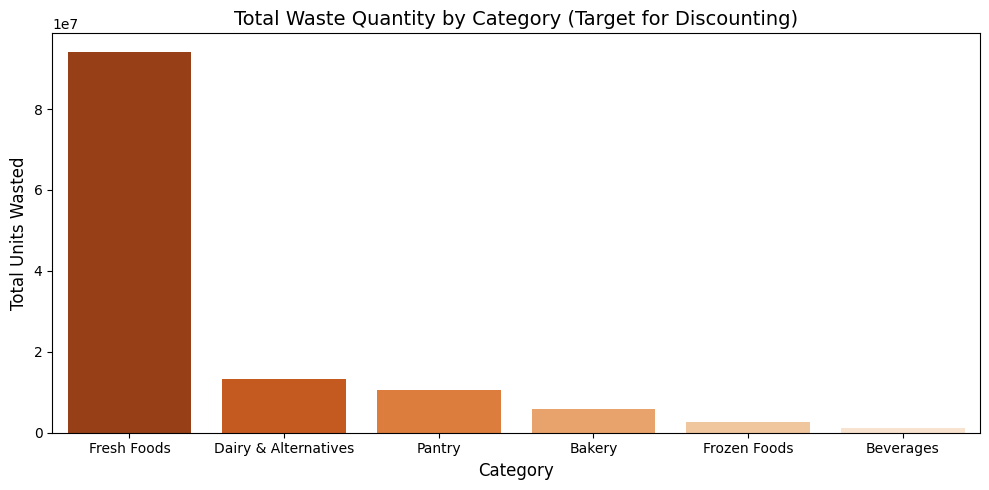

In [9]:
# 2A. Analyze Waste by Store Location
plt.figure(figsize=(12, 6))
waste_by_store = df.groupby('store_location')['waste_quantity'].sum().sort_values(ascending=False)
sns.barplot(x=waste_by_store.index, y=waste_by_store.values, palette='Reds_r')

plt.title('Total Waste Quantity by Store Location (Target for Redistribution)', fontsize=14)
plt.xlabel('Store Location', fontsize=12)
plt.ylabel('Total Units Wasted', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2B. Analyze Waste by Product Category
plt.figure(figsize=(10, 5))
waste_by_category = df.groupby('category')['waste_quantity'].sum().sort_values(ascending=False)
sns.barplot(x=waste_by_category.index, y=waste_by_category.values, palette='Oranges_r')

plt.title('Total Waste Quantity by Category (Target for Discounting)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Units Wasted', fontsize=12)
plt.tight_layout()
plt.show()

# Step 3: Price Elasticity & Freshness Sensitivity
**Tagline:** Mapping consumer demand against dynamic discounting.

**Description:** This step feeds directly into the Demand Agent. We evaluate how different discount tiers (`discount_applied_percent`) influence the `sales_volume`. This mathematically proves whether early, moderate discounts are better than late, aggressive discounts for items nearing expiry.

C:\Users\sanke\AppData\Local\Temp\ipykernel_22448\2889908246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='discount_applied_percent', y='sales_volume', data=discount_impact, palette='Greens_d')


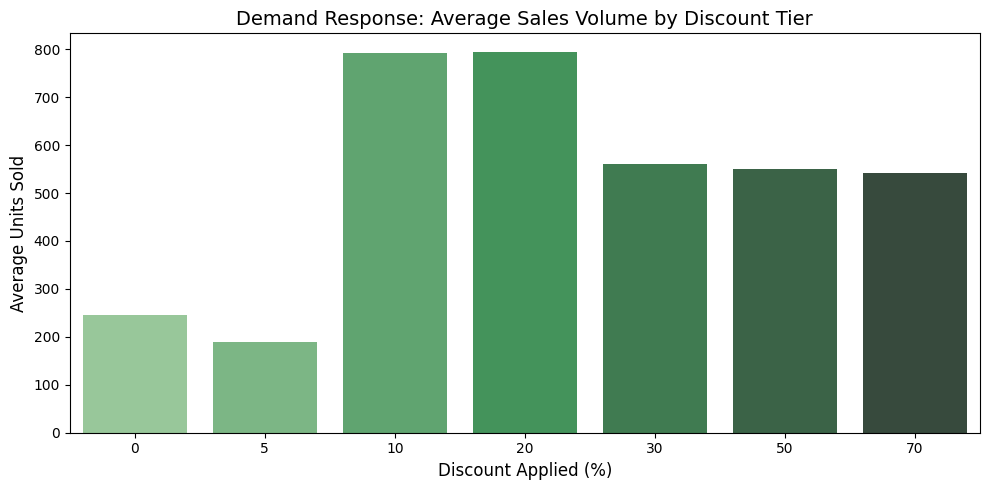

Demand Agent Rule Thresholds:
   discount_applied_percent  sales_volume
0                         0    245.446202
1                         5    189.856354
2                        10    792.493082
3                        20    793.385417
4                        30    559.994819
5                        50    550.769836
6                        70    541.302624


In [10]:
plt.figure(figsize=(10, 5))

# Calculate average sales volume for each discount tier
discount_impact = df.groupby('discount_applied_percent')['sales_volume'].mean().reset_index()

sns.barplot(x='discount_applied_percent', y='sales_volume', data=discount_impact, palette='Greens_d')

plt.title('Demand Response: Average Sales Volume by Discount Tier', fontsize=14)
plt.xlabel('Discount Applied (%)', fontsize=12)
plt.ylabel('Average Units Sold', fontsize=12)
plt.tight_layout()
plt.show()

# Display logic thresholds for the Demand Agent
print("Demand Agent Rule Thresholds:")
print(discount_impact)

# Step 4: Environmental Impact on Spoilage
**Tagline:** Correlating severe weather events with inventory loss.

**Description:** The Weather Impact Agent needs statistical evidence. This block plots `weather_severity_n` against average `waste_quantity` to determine if adverse conditions (like extreme heat or monsoons) directly increase the spoilage rate.

C:\Users\sanke\AppData\Local\Temp\ipykernel_22448\57166442.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_severity_n', y='waste_quantity', data=weather_waste, palette='Blues_d')


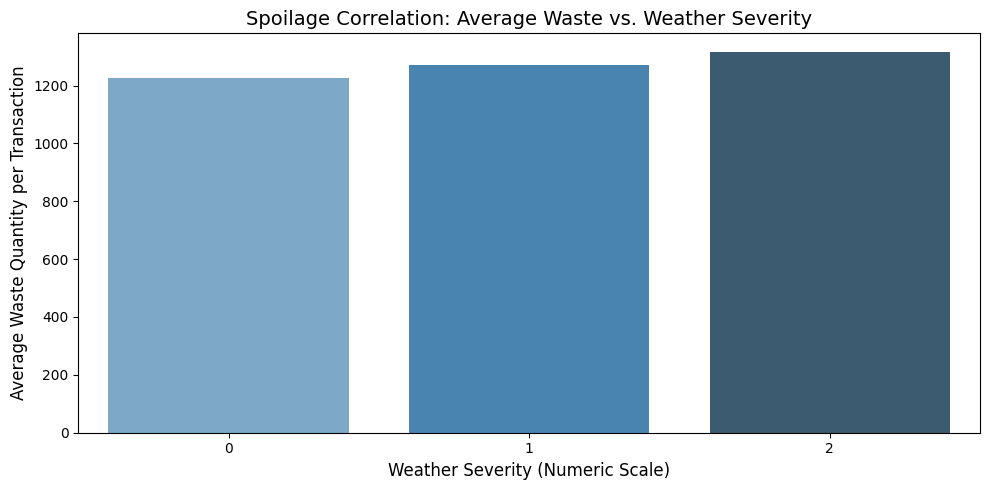

In [11]:
plt.figure(figsize=(10, 5))

# Calculate average waste per weather severity level
weather_waste = df.groupby('weather_severity_n')['waste_quantity'].mean().reset_index()

sns.barplot(x='weather_severity_n', y='waste_quantity', data=weather_waste, palette='Blues_d')

plt.title('Spoilage Correlation: Average Waste vs. Weather Severity', fontsize=14)
plt.xlabel('Weather Severity (Numeric Scale)', fontsize=12)
plt.ylabel('Average Waste Quantity per Transaction', fontsize=12)
plt.tight_layout()
plt.show()

# Step 5: Supply Chain Bottlenecks
**Tagline:** Profiling vendor reliability for scenario simulation.

**Description:** To build the Simulation engine (Phase 4), we analyze logistical delays. This maps out which `supplier_id` causes the most `supply_delay_days`. The Inventory Agent uses this to preemptively adjust order sizes from unreliable vendors to prevent shelf-life expiration before arrival.

C:\Users\sanke\AppData\Local\Temp\ipykernel_22448\2460496292.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='supplier_id', y='supply_delay_days', data=supply_delay, palette='Purples_r')


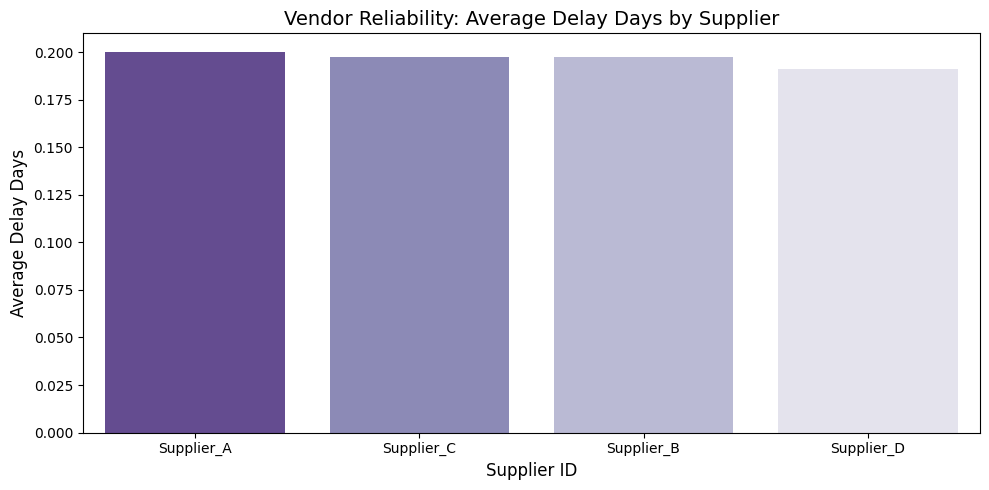

In [12]:
plt.figure(figsize=(10, 5))

# Determine average delay days per supplier
supply_delay = df.groupby('supplier_id')['supply_delay_days'].mean().sort_values(ascending=False).reset_index()

sns.barplot(x='supplier_id', y='supply_delay_days', data=supply_delay, palette='Purples_r')

plt.title('Vendor Reliability: Average Delay Days by Supplier', fontsize=14)
plt.xlabel('Supplier ID', fontsize=12)
plt.ylabel('Average Delay Days', fontsize=12)
plt.tight_layout()
plt.show()

# Step 6: Financial Baseline & Objective Optimization
**Tagline:** Establishing the Linear Programming objective function.

**Description:** The ultimate goal of the Decision Agent is optimization. This code calculates the actual realized profit against the total capital lost to waste. By visualizing this massive discrepancy, it hardcodes the AI's primary optimization objective: prioritize minimizing waste over maximizing unit margins.

C:\Users\sanke\AppData\Local\Temp\ipykernel_22448\2049763929.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Amount', data=profit_data, palette=['#2ca02c', '#d62728'])


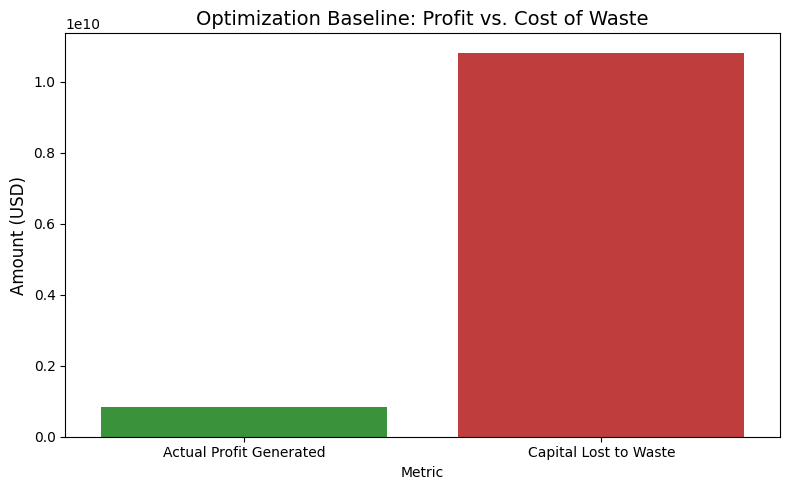

--- Linear Programming Baseline ---
Total Profit Generated: $828,623,479.60
Total Capital Lost to Waste: $10,829,870,843.31


In [13]:
# Calculate total actual profit vs. capital lost to unsold inventory
total_profit = df['final_profit'].sum()
cost_of_waste = (df['waste_quantity'] * df['cost_price']).sum()

profit_data = pd.DataFrame({
    'Metric': ['Actual Profit Generated', 'Capital Lost to Waste'],
    'Amount': [total_profit, cost_of_waste]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Amount', data=profit_data, palette=['#2ca02c', '#d62728'])

plt.title('Optimization Baseline: Profit vs. Cost of Waste', fontsize=14)
plt.ylabel('Amount (USD)', fontsize=12)
plt.tight_layout()
plt.show()

# Output the baseline metrics for the Linear Programming model
print("--- Linear Programming Baseline ---")
print(f"Total Profit Generated: ${total_profit:,.2f}")
print(f"Total Capital Lost to Waste: ${cost_of_waste:,.2f}")

# Step 7: Time-Series Demand Trends
**Tagline:** Mapping sales volume fluctuations over time.

**Description:** To forecast future demand, the Demand Agent needs to understand historical time-series trends. This step aggregates total sales volume by month to identify seasonal peaks and overall demand trajectories across the dataset.

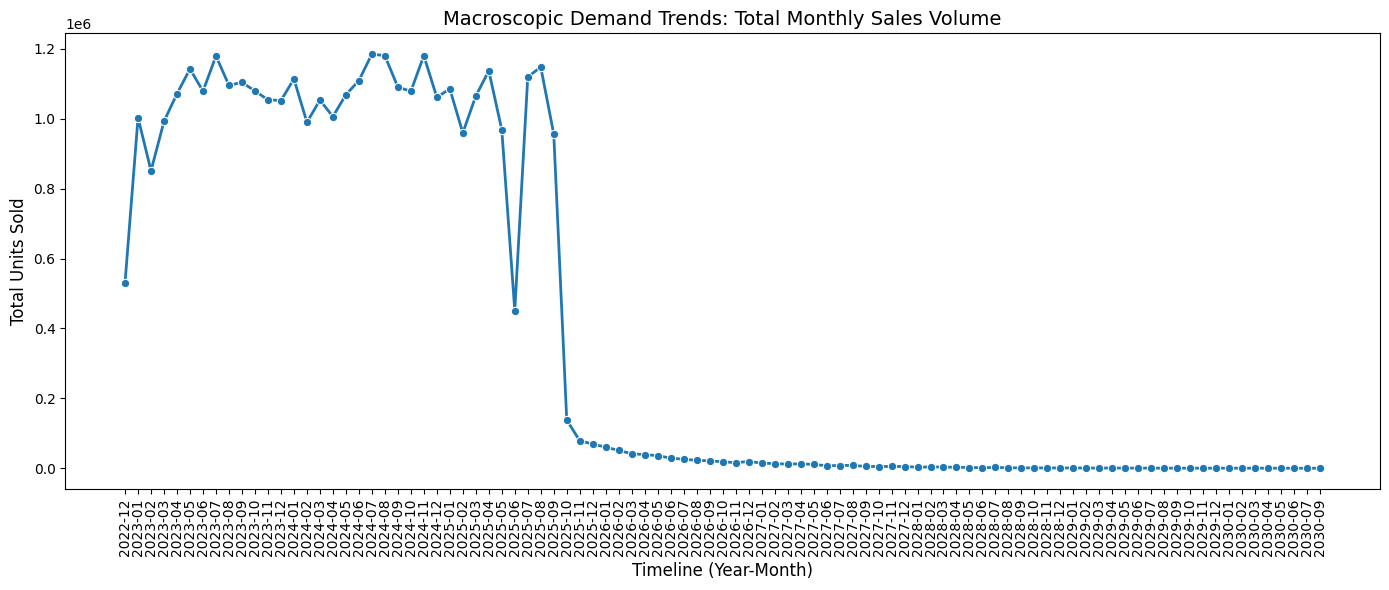

In [16]:
# ==========================================
# STEP 7: TIME-SERIES DEMAND TRENDS
# ==========================================
import matplotlib.dates as mdates

# Convert sales_date to datetime if not already
df['sales_date'] = pd.to_datetime(df['sales_date'])

# Group by Year-Month to see macroscopic demand trends
df['sales_month'] = df['sales_date'].dt.to_period('M')
monthly_demand = df.groupby('sales_month')['sales_volume'].sum().reset_index()

# Convert back to string/datetime for plotting
monthly_demand['sales_month'] = monthly_demand['sales_month'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(x='sales_month', y='sales_volume', data=monthly_demand, marker='o', color='#1f77b4', linewidth=2)

plt.title('Macroscopic Demand Trends: Total Monthly Sales Volume', fontsize=14)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Drop the temporary column to keep dataset clean
df.drop(columns=['sales_month'], inplace=True)

# Step 8: Expiry Timelines & Spoilage Risk Danger Zones
**Tagline:** Visualizing the countdown to inventory death.

**Description:** To answer the LangChain query *"Which store has the highest spoilage risk this week?"*, the Inventory Agent needs to understand the distribution of remaining shelf life. This step visualizes the `Days_to_Expiry_at_Sale` to show exactly how much inventory sits in the "Danger Zone" (0-3 days before expiry).

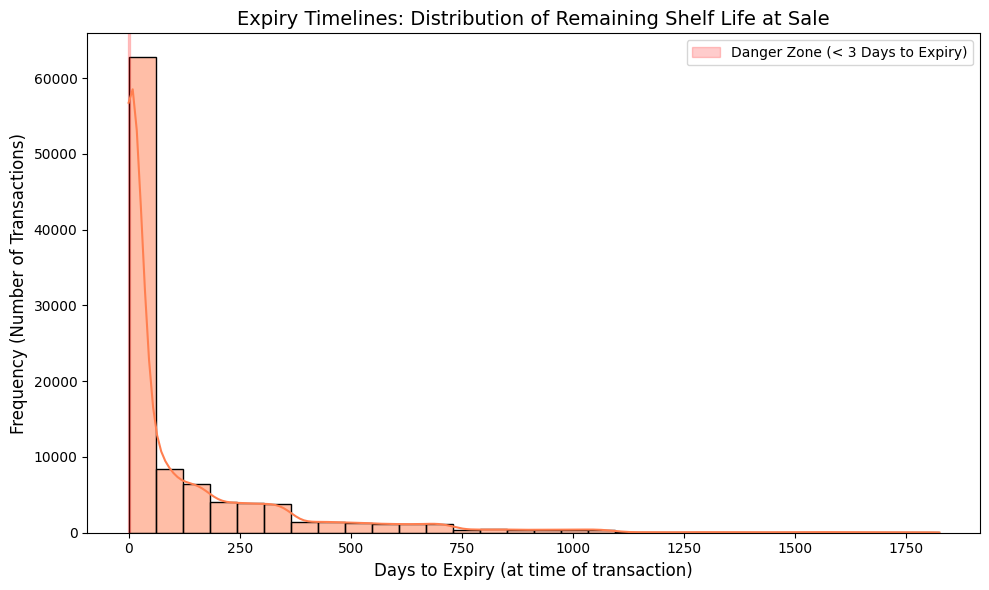

Transactions occurring in the Spoilage Danger Zone (<= 3 days): 29535


In [15]:
# ==========================================
# STEP 8: EXPIRY TIMELINES & DANGER ZONES
# ==========================================
plt.figure(figsize=(10, 6))

# Plot a histogram to show the distribution of days left until expiry
sns.histplot(df['Days_to_Expiry_at_Sale'], bins=30, kde=True, color='coral')

# Highlight the "Danger Zone" (0 to 3 days left)
plt.axvspan(-2, 3, color='red', alpha=0.2, label='Danger Zone (< 3 Days to Expiry)')

plt.title('Expiry Timelines: Distribution of Remaining Shelf Life at Sale', fontsize=14)
plt.xlabel('Days to Expiry (at time of transaction)', fontsize=12)
plt.ylabel('Frequency (Number of Transactions)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Logic Rule extraction for LangChain Spoilage Risk Query
danger_zone_count = df[df['Days_to_Expiry_at_Sale'] <= 3].shape[0]
print(f"Transactions occurring in the Spoilage Danger Zone (<= 3 days): {danger_zone_count}")